In [1]:
from argparse import Namespace
from pathlib import Path
import sys

from IPython.display import display
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.build import build_dataset, build_loader, load_config_defaults, load_predictor
from src.predict.sds.diffusivity import DiffusivitySolver, compute_diffusivity
from src.predict.sds.sa import compute_surface_area
from src.predict.sds.tpc import compute_tpc
from src.predict.sds.vf import compute_volume_fraction
from src.predict.types import AnchorSlice, PredictOptions


def to_phase_image(sample, num_phases):
    image = sample.detach().cpu()[0].clamp(-1.0, 1.0)
    image = ((image + 1.0) * 0.5 * (num_phases - 1)).round()
    return image.numpy().astype(np.uint8)


def phase_fraction(values, num_phases):
    counts = np.bincount(values.reshape(-1), minlength=num_phases)
    return counts / counts.sum()


def phase_values(images, num_phases):
    array = np.asarray(images, dtype=np.float32)
    array = array / (num_phases - 1) * 2.0 - 1.0
    return torch.from_numpy(array.copy()).float()


In [2]:
RUN_DIR = None
TARGET_IMAGE_COUNT = 64

run_dir = Path(RUN_DIR) if RUN_DIR else max(
    [p for p in (ROOT / "run").glob("*") if (p / "diffusion.yaml").is_file()],
    key=lambda p: p.stat().st_mtime,
)
run_dir = run_dir if run_dir.is_absolute() else ROOT / run_dir

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
args = Namespace(**load_config_defaults(run_dir / "vae.yaml"))
args.data_dir = Path(args.data_dir)
args.data_dir = args.data_dir if args.data_dir.is_absolute() else ROOT / args.data_dir
args.batch_size = TARGET_IMAGE_COUNT + 1

num_phases = args.num_phases
dataset = build_dataset(args)
batch = next(build_loader(dataset, args, device=torch.device("cpu")))

anchor_image = to_phase_image(batch[0], num_phases)
target_images = [to_phase_image(sample, num_phases) for sample in batch[1:]]
anchor = AnchorSlice(image=anchor_image, axis=0, index=anchor_image.shape[0] // 2)
options = PredictOptions(
    num_phases=num_phases,
    anchor_weight=1.0,
    sds_weight=1.0,
    sds_steps=100,
    sds_slice_steps=1,
    sds_lr=1.0e-2,
    vf_weight=1.0,
    tpc_weight=1.0,
    sa_weight=1.0,
    diffusivity_weight=1.0,
    diffusivity_size=32,
    refine_steps=1,
)

predictor = load_predictor(run_dir, device=device)
volume, stats = predictor.predict(options, anchors=[anchor], target_images=target_images)
volume_np = volume.detach().cpu().numpy()
volume_vf = phase_fraction(volume_np, num_phases)
target_vf = np.stack([phase_fraction(image, num_phases) for image in target_images]).mean(axis=0)
stats = {key: float(value.detach().cpu()) for key, value in stats.items() if torch.is_tensor(value) and value.numel() == 1}

print("run dir:", run_dir)
print("anchor:", (anchor.axis, anchor.index), "target images:", len(target_images))
print("volume:", volume_np.shape, "phases:", np.unique(volume_np).tolist())
print("target vf:", target_vf.round(4).tolist())
print("volume vf:", volume_vf.round(4).tolist())
print("stats:", stats)

run dir: D:\code\microlad\run\20260628-091822-400207
anchor: (0, 32) target images: 64
volume: (64, 64, 64) phases: [0, 1, 2]
target vf: [0.2999, 0.1276, 0.5725]
volume vf: [0.201, 0.1624, 0.6366]
stats: {'sds': 0.02914327010512352, 'vf': 0.005104293115437031, 'tpc': 0.0023270254023373127, 'sa': 0.000644079118501395, 'diffusivity': 0.005593736656010151, 'loss': 0.04281240329146385, 'steps': 100.0}


metric       phase       target    generated          error
vf               0     0.299885     0.201025       0.098859
vf               1     0.127664     0.162377       0.034713
vf               2     0.572451     0.636598       0.064147
sa               0     0.151768     0.120125       0.031643
sa               1     0.096619     0.127756       0.031138
sa               2     0.182533     0.175092       0.007441
diffusivity      0     0.087528     0.016508       0.071020
diffusivity      1     0.019540     0.027374       0.007834
diffusivity      2     0.254527     0.296368       0.041841
tpc              0      profile      profile   mae 0.053942
tpc              1      profile      profile   mae 0.011507
tpc              2      profile      profile   mae 0.077941


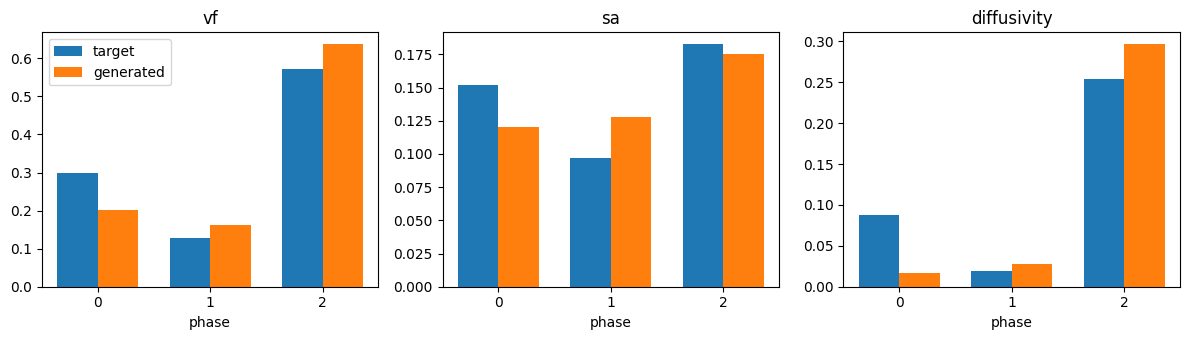

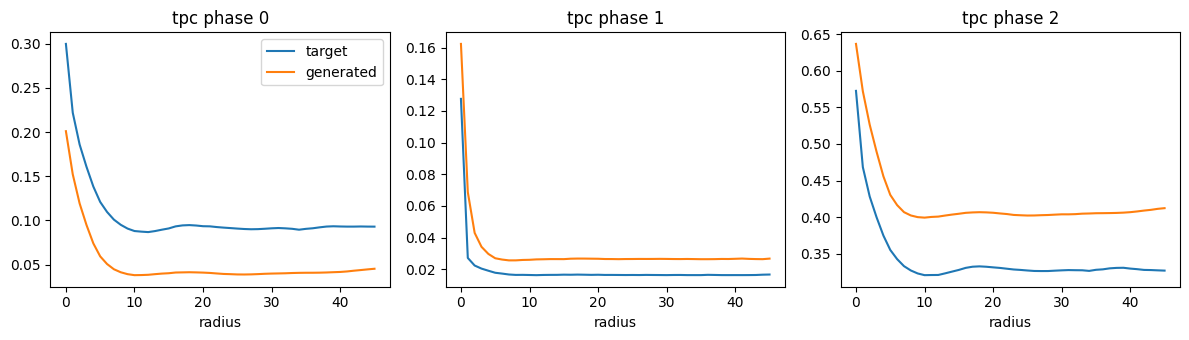

In [3]:
target_values = phase_values(target_images, num_phases)
generated_values = phase_values(volume_np, num_phases)
rows = []
plots = []


def add_phase_metric(name, target, generated):
    target_np = target.detach().cpu().numpy()
    generated_np = generated.detach().cpu().numpy()
    diff_np = np.abs(generated_np - target_np)
    for phase, (target_value, generated_value, diff_value) in enumerate(zip(target_np, generated_np, diff_np)):
        rows.append((name, phase, f"{target_value:.6f}", f"{generated_value:.6f}", f"{diff_value:.6f}"))
    plots.append((name, target_np, generated_np))


with torch.no_grad():
    if options.vf_weight > 0.0:
        add_phase_metric(
            "vf",
            compute_volume_fraction(target_values, num_phases=num_phases),
            compute_volume_fraction(generated_values, num_phases=num_phases),
        )
    if options.sa_weight > 0.0:
        add_phase_metric(
            "sa",
            compute_surface_area(target_values, num_phases=num_phases),
            compute_surface_area(generated_values, num_phases=num_phases),
        )
    if options.diffusivity_weight > 0.0:
        size = options.diffusivity_size or target_images[0].shape
        height, width = (size, size) if isinstance(size, int) else size
        solver = DiffusivitySolver(height=height, width=width, low_cond=options.diffusivity_low_cond)
        add_phase_metric(
            "diffusivity",
            compute_diffusivity(target_values, solver=solver, num_phases=num_phases),
            compute_diffusivity(generated_values, solver=solver, num_phases=num_phases),
        )
    if options.tpc_weight > 0.0:
        target_tpc = compute_tpc(target_values, num_phases=num_phases)
        generated_tpc = compute_tpc(generated_values, num_phases=num_phases)
        tpc_mae = (generated_tpc - target_tpc).abs().mean(dim=1).detach().cpu().numpy()
        for phase, value in enumerate(tpc_mae):
            rows.append(("tpc", phase, "profile", "profile", f"mae {value:.6f}"))

print(f"{'metric':<12} {'phase':>5} {'target':>12} {'generated':>12} {'error':>14}")
for name, phase, target_value, generated_value, error in rows:
    print(f"{name:<12} {phase:>5d} {target_value:>12} {generated_value:>12} {error:>14}")

if plots:
    fig, axes = plt.subplots(1, len(plots), figsize=(4 * len(plots), 3.5), squeeze=False)
    x = np.arange(num_phases)
    for ax, (name, target_np, generated_np) in zip(axes.ravel(), plots):
        ax.bar(x - 0.18, target_np, width=0.36, label="target")
        ax.bar(x + 0.18, generated_np, width=0.36, label="generated")
        ax.set_title(name)
        ax.set_xticks(x)
        ax.set_xlabel("phase")
    axes.ravel()[0].legend()
    plt.tight_layout()

if options.tpc_weight > 0.0:
    fig, axes = plt.subplots(1, num_phases, figsize=(4 * num_phases, 3.5), squeeze=False)
    target_tpc_np = target_tpc.detach().cpu().numpy()
    generated_tpc_np = generated_tpc.detach().cpu().numpy()
    for phase, ax in enumerate(axes.ravel()):
        ax.plot(target_tpc_np[phase], label="target")
        ax.plot(generated_tpc_np[phase], label="generated")
        ax.set_title(f"tpc phase {phase}")
        ax.set_xlabel("radius")
    axes.ravel()[0].legend()
    plt.tight_layout()


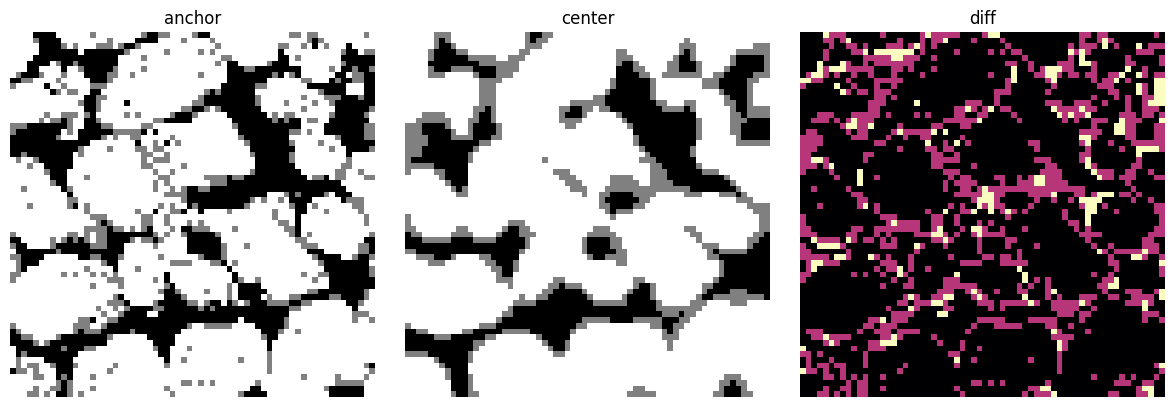

In [4]:
center = volume_np[anchor.index]
diff = np.abs(center.astype(np.int16) - anchor_image.astype(np.int16))
items = [("anchor", anchor_image, "gray", 0, num_phases - 1), ("center", center, "gray", 0, num_phases - 1), ("diff", diff, "magma", 0, max(1, num_phases - 1))]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), squeeze=False)
for ax, (title, image, cmap, vmin, vmax) in zip(axes.ravel(), items):
    ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()

In [5]:
axis_picker = widgets.Dropdown(
    options=[("axis 0", 0), ("axis 1", 1), ("axis 2", 2)],
    value=anchor.axis,
    description="axis",
)
index_slider = widgets.IntSlider(
    value=anchor.index,
    min=0,
    max=volume_np.shape[anchor.axis] - 1,
    step=1,
    description="index",
    continuous_update=True,
)
out = widgets.Output()


def take_slice(axis, index):
    if axis == 0:
        return volume_np[index]
    if axis == 1:
        return volume_np[:, index, :]
    return volume_np[:, :, index]


def update_index_range(change=None):
    index_slider.max = volume_np.shape[axis_picker.value] - 1
    index_slider.value = min(index_slider.value, index_slider.max)


def show_slice(change=None):
    axis = axis_picker.value
    index = index_slider.value
    with out:
        out.clear_output(wait=True)
        plt.figure(figsize=(5, 5))
        plt.imshow(take_slice(axis, index), cmap="gray", vmin=0, vmax=num_phases - 1, interpolation="nearest")
        plt.title(f"axis {axis}, index {index}")
        plt.axis("off")
        plt.show()


axis_picker.observe(update_index_range, names="value")
axis_picker.observe(show_slice, names="value")
index_slider.observe(show_slice, names="value")

display(widgets.HBox([axis_picker, index_slider]), out)
show_slice()


Output()